In [ ]:
import ast
import pandas as pd
import os
from collections import Counter
from tqdm import tqdm

# ================= Configuration =================


REVIEW_FILE = 'steam.json'      
META_FILE = 'steam_games.json'    
OUTPUT_FILE = 'steam_sequential_dataset.csv'

MIN_INTERACTIONS = 20  
MIN_ITEM_INTERACTIONS = 5 
EST_REVIEW_LINES = 7793069 
EST_META_LINES = 32135

# ================= Utility Functions =================

def parse_steam_date(date_str):
    if not date_str:
        return None
    try:
        clean_date = date_str.replace("Posted: ", "").strip()
        if "Updated:" in clean_date:
            clean_date = clean_date.split("Updated:")[0].strip()
        if "," not in clean_date: 
            clean_date += ", 2016" 
        return pd.to_datetime(clean_date, errors='coerce')
    except:
        return None

def load_game_metadata(filepath):
    print(f"loading: {filepath} ...")
    meta_dict = {}
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=EST_META_LINES, unit="game"):
            try:
                entry = ast.literal_eval(line.strip())
                item_id = str(entry.get('id'))
                genres = entry.get('genres')
                tags = entry.get('tags')
                
                category_str = "Unknown"
                if genres and len(genres) > 0:
                    category_str = "|".join(genres)
                elif tags and len(tags) > 0:
                    category_str = "|".join(tags)
                
                meta_dict[item_id] = category_str
                
            except Exception:
                continue
                
    print(f"find original # of {len(meta_dict)} categories")
    return meta_dict

In [ ]:
def process_steam_data():
    OUTPUT_FILE = 'steam_sequential_dataset.csv' 
    
    REVIEW_FILE = 'steam.json'
    META_FILE = 'steam_games.json'
    
    MIN_INTERACTIONS = 20
    MIN_ITEM_INTERACTIONS = 5
    EST_REVIEW_LINES = 7793069
    game_category_map = load_game_metadata(META_FILE)
    
    user_counter = Counter()
    item_counter = Counter()
    
    print(f"\nPhase 1: scanning Review ...")
    with open(REVIEW_FILE, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=EST_REVIEW_LINES, unit="line", mininterval=0.5):
            try:
                entry = ast.literal_eval(line.strip())
                username = entry.get('username')
                raw_item_id = entry.get('product_id')
                
                if username:
                    user_counter[username] += 1
                if raw_item_id:
                    item_counter[str(raw_item_id)] += 1
            except:
                continue

    print("\n filter...")
    valid_users_set = set(u for u, c in user_counter.items() if c >= MIN_INTERACTIONS)
    valid_items_set = set(item for item, c in item_counter.items() if c >= MIN_ITEM_INTERACTIONS)
    
    print(f"# of User (Raw): {len(valid_users_set)}")
    print(f"# of Items (Raw): {len(valid_items_set)}")

    print(f"\nPhase 2: matching...")
    data_list = []
    
    with open(REVIEW_FILE, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=EST_REVIEW_LINES, unit="line", mininterval=0.5):
            try:
                entry = ast.literal_eval(line.strip())
                username = entry.get('username')
                if username not in valid_users_set:
                    continue
                raw_item_id = entry.get('product_id') 
                if not raw_item_id:
                    continue
                item_id_str = str(raw_item_id)
                if item_id_str not in valid_items_set:
                    continue
                category = game_category_map.get(item_id_str, "Unknown")
                
                date_str = entry.get('date') or entry.get('date_posted')
                dt_obj = parse_steam_date(date_str)
                if dt_obj is pd.NaT or dt_obj is None:
                    continue 
                hours = entry.get('hours', 0.0)
                data_list.append({
                    'username_raw': username,
                    'item_id_raw': item_id_str,
                    'timestamp': dt_obj,
                    'category': category,
                    'hours': hours
                })
            except Exception:
                continue

    print("\nPhase 3:  DataFrame ...")
    df = pd.DataFrame(data_list)
    
    if df.empty:
        print("DataFrame is null")
        return

    df = df.sort_values(by=['username_raw', 'timestamp'])

    print(" ID (1 to N)...")
    unique_users = df['username_raw'].unique()
    user_map = {name: i + 1 for i, name in enumerate(unique_users)}
    df['user_id'] = df['username_raw'].map(user_map)

    unique_items = df['item_id_raw'].unique()
    item_map = {item: i + 1 for i, item in enumerate(unique_items)}
    df['item_id'] = df['item_id_raw'].map(item_map)
    final_cols = ['user_id', 'item_id', 'timestamp', 'category', 'hours']
    final_df = df[final_cols]
    final_df = final_df.sort_values(by=['user_id', 'timestamp'])
    
    # ================= New Feature: Add Game Title =================
    NEW_OUTPUT_FILE = 'steam_sequential_dataset_with_title.csv'
    
    def load_game_titles(filepath):
        print(f"Loading titles from {filepath}...")
        title_map = {}
        if not os.path.exists(filepath):
            return title_map
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    entry = ast.literal_eval(line.strip())
                    game_id = str(entry.get('id'))
                    title = entry.get('app_name') or entry.get('title')
                    
                    if game_id and title:
                        title_map[game_id] = title
                except:
                    continue
        return title_map

    game_title_map = load_game_titles(META_FILE)
    print("Mapping game titles...")
    df['title'] = df['item_id_raw'].map(game_title_map).fillna('Unknown')
    final_cols = ['user_id', 'item_id', 'timestamp', 'category', 'hours', 'title']
    final_df = df[final_cols].sort_values(by=['user_id', 'timestamp'])
    print(f"\\nSaving to {NEW_OUTPUT_FILE}...")
    final_df.to_csv(NEW_OUTPUT_FILE, index=False)
    print(f"Done. Saved with titles.")
    
    
    print(f"\nPhase 4: save to {OUTPUT_FILE}...")
    final_df.to_csv(OUTPUT_FILE, index=False)
    
    print("="*40)
    print(f"saved to: {os.path.abspath(OUTPUT_FILE)}")
    print(f"# of records: {len(final_df)}")
    print("="*40)

if __name__ == "__main__":
    process_steam_data()

In [ ]:
import pandas as pd
from collections import Counter
import os


OUTPUT_FILE = 'steam_sequential_dataset.csv'

def analyze_category_combinations():
    print(f"Reading file: {OUTPUT_FILE} ...")
    
    try:
        # 1. Read CSV
        df = pd.read_csv(OUTPUT_FILE, usecols=['category'])
        print(f"Read successfully. Total rows: {len(df)}.")
        
        # 2. Fill missing values
        df['category'] = df['category'].fillna('Unknown')
        
        print("Counting category combinations...")
        
        # 3. Count combinations
        combo_counts = Counter(df['category'])
        
        # 4. Sort by frequency (descending)
        sorted_combos = sorted(combo_counts.items(), key=lambda x: x[1], reverse=True)
        
        # 5. Print results
        print("\n" + "=" * 60)
        print("Category Combination Statistics Report")
        print(f"Total number of unique category combinations: {len(sorted_combos)}")
        print("=" * 60)
        print(f"{'Category Combination (Raw String)':<40} | {'Count':<10}")
        print("-" * 55)
        
        for combo, count in sorted_combos:
            display_name = (combo[:37] + '..') if len(combo) > 37 else combo
            print(f"{display_name:<40} | {count:<10}")
            
        print("=" * 60)
        
        # 6. Save statistics to file
        save_path = 'category_combination_stats.csv'
        print(f"\nSaving statistics to {save_path} ...")
        stats_df = pd.DataFrame(sorted_combos, columns=['combination', 'count'])
        stats_df.to_csv(save_path, index=False)
        print("Save completed.")

    except FileNotFoundError:
        print(f"Error: File not found: {OUTPUT_FILE}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

if __name__ == "__main__":
    analyze_category_combinations()


In [ ]:
import ast
import pandas as pd
import os
from collections import Counter
from tqdm import tqdm

# ================= Configuration =================
# [Modification] All files are defined directly in the root directory
REVIEW_FILE = 'steam.json'
META_FILE = 'steam_games.json'
OUTPUT_FILE = 'steam_sequential_dataset.csv'

MIN_INTERACTIONS = 20       # Filter users with fewer than 20 interactions
MIN_ITEM_INTERACTIONS = 5  # Filter items with fewer than 5 occurrences
EST_REVIEW_LINES = 7793069 # Estimated number of lines for progress bar
# =================================================

def load_game_metadata(meta_file):
    print(f"Loading metadata from {meta_file}...")
    mapping = {}
    if not os.path.exists(meta_file):
        print(f"Warning: {meta_file} not found. Categories will be set to 'Unknown'.")
        return mapping
        
    with open(meta_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                item = ast.literal_eval(line.strip())
                if 'id' in item and 'genres' in item:
                    # Convert list to a pipe-separated string (e.g., "Action|Adventure")
                    genres = item['genres']
                    if isinstance(genres, list):
                        mapping[str(item['id'])] = "|".join(genres)
                    else:
                        mapping[str(item['id'])] = str(genres)
            except:
                continue
    print(f"Loaded categories for {len(mapping)} games.")
    return mapping

def parse_steam_date(date_str):
    if not date_str or pd.isna(date_str):
        return None
    try:
        # Common format: "Posted November 5, 2015."
        clean_date = date_str.replace("Posted", "").replace(".", "").strip()
        return pd.to_datetime(clean_date, format="%B %d, %Y", errors='coerce')
    except:
        return None

def process_steam_data():
    # --- Step 0: Load game metadata ---
    game_category_map = load_game_metadata(META_FILE)
    
    user_counter = Counter()
    item_counter = Counter()
    
    print(f"\nPhase 1: Scanning review file to count user and item activity...")
    # --- Step 1: Count interactions ---
    with open(REVIEW_FILE, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=EST_REVIEW_LINES, unit="line", mininterval=0.5):
            try:
                entry = ast.literal_eval(line.strip())
                username = entry.get('username')
                raw_item_id = entry.get('product_id')
                
                if username:
                    user_counter[username] += 1
                if raw_item_id:
                    item_counter[str(raw_item_id)] += 1
            except:
                continue

    # --- Step 2: Determine valid sets ---
    print("\nFiltering users and items based on thresholds...")
    valid_users_set = set(u for u, c in user_counter.items() if c >= MIN_INTERACTIONS)
    valid_items_set = set(item for item, c in item_counter.items() if c >= MIN_ITEM_INTERACTIONS)
    
    print(f"Number of valid users (raw): {len(valid_users_set)}")
    print(f"Number of valid items (raw): {len(valid_items_set)}")

    # --- Step 3: Extract data ---
    print(f"\nPhase 2: Extracting interactions and matching categories...")
    data_list = []
    
    with open(REVIEW_FILE, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=EST_REVIEW_LINES, unit="line", mininterval=0.5):
            try:
                entry = ast.literal_eval(line.strip())
                username = entry.get('username')
                
                # 1. Filter users
                if username not in valid_users_set:
                    continue
                
                # 2. Filter items
                raw_item_id = entry.get('product_id') 
                if not raw_item_id:
                    continue
                item_id_str = str(raw_item_id)
                
                if item_id_str not in valid_items_set:
                    continue
                
                # 3. Match category
                category = game_category_map.get(item_id_str, "Unknown")
                
                # 4. Parse timestamp
                date_str = entry.get('date') or entry.get('date_posted')
                dt_obj = parse_steam_date(date_str)
                if dt_obj is pd.NaT or dt_obj is None:
                    continue 
                
                # 5. [Key] Extract hours
                hours = entry.get('hours', 0.0)

                data_list.append({
                    'username_raw': username,
                    'item_id_raw': item_id_str,
                    'timestamp': dt_obj,
                    'category': category,
                    'hours': hours  # Ensure this field is included
                })
                
            except Exception:
                continue

    # --- Step 4: Final processing ---
    print("\nPhase 3: Creating DataFrame and re-indexing user/item IDs...")
    df = pd.DataFrame(data_list)
    
    if df.empty:
        print("Warning: DataFrame is empty! Please check the filtering conditions.")
        return

    # Sort by user and time
    df = df.sort_values(by=['username_raw', 'timestamp'])

    print("Generating continuous IDs (from 1 to N)...")
    unique_users = df['username_raw'].unique()
    user_map = {name: i + 1 for i, name in enumerate(unique_users)}
    df['user_id'] = df['username_raw'].map(user_map)

    unique_items = df['item_id_raw'].unique()
    item_map = {item: i + 1 for i, item in enumerate(unique_items)}
    df['item_id'] = df['item_id_raw'].map(item_map)
    
    # [Key] Final column selection, must include hours
    final_cols = ['user_id', 'item_id', 'timestamp', 'category', 'hours']
    final_df = df[final_cols]
    
    final_df = final_df.sort_values(by=['user_id', 'timestamp'])
    
    print(f"\nPhase 4: Saving output to root directory: {OUTPUT_FILE}...")
    final_df.to_csv(OUTPUT_FILE, index=False)
    
    print("=" * 40)
    print("Processing completed!")
    print(f"File location: {os.path.abspath(OUTPUT_FILE)}")
    print(f"Total number of records: {len(final_df)}")
    print("[Verification] Preview of the first 3 rows (check the hours column):")
    print(final_df.head(3))
    print("=" * 40)

if __name__ == "__main__":
    process_steam_data()

STEAM CATEGORY MAPPING (Overwrite Mode)

[1/4] Loading steam_sequential_dataset.csv...
   Dataset loaded: 1,796,494 records
   [CHECK] 'hours' column exists. (Mean: 73.71)

[2/4] Mapping categories and overwriting 'category' column...
   Mapping complete: Reduced 925 complex types to 44 primary types.

[3/4] Saving to steam_sequential_mapped.csv...
   Saved successfully! Path: d:\work\echo\datasets\Steam\steam_sequential_mapped.csv
   Final Columns: ['user_id', 'item_id', 'timestamp', 'category', 'hours', 'title']

[4/4] Generating Visualization...


C:\Users\61673\AppData\Local\Temp\ipykernel_56704\2883111733.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0], palette='viridis')


   Plot saved as 'category_distribution_analysis.png'


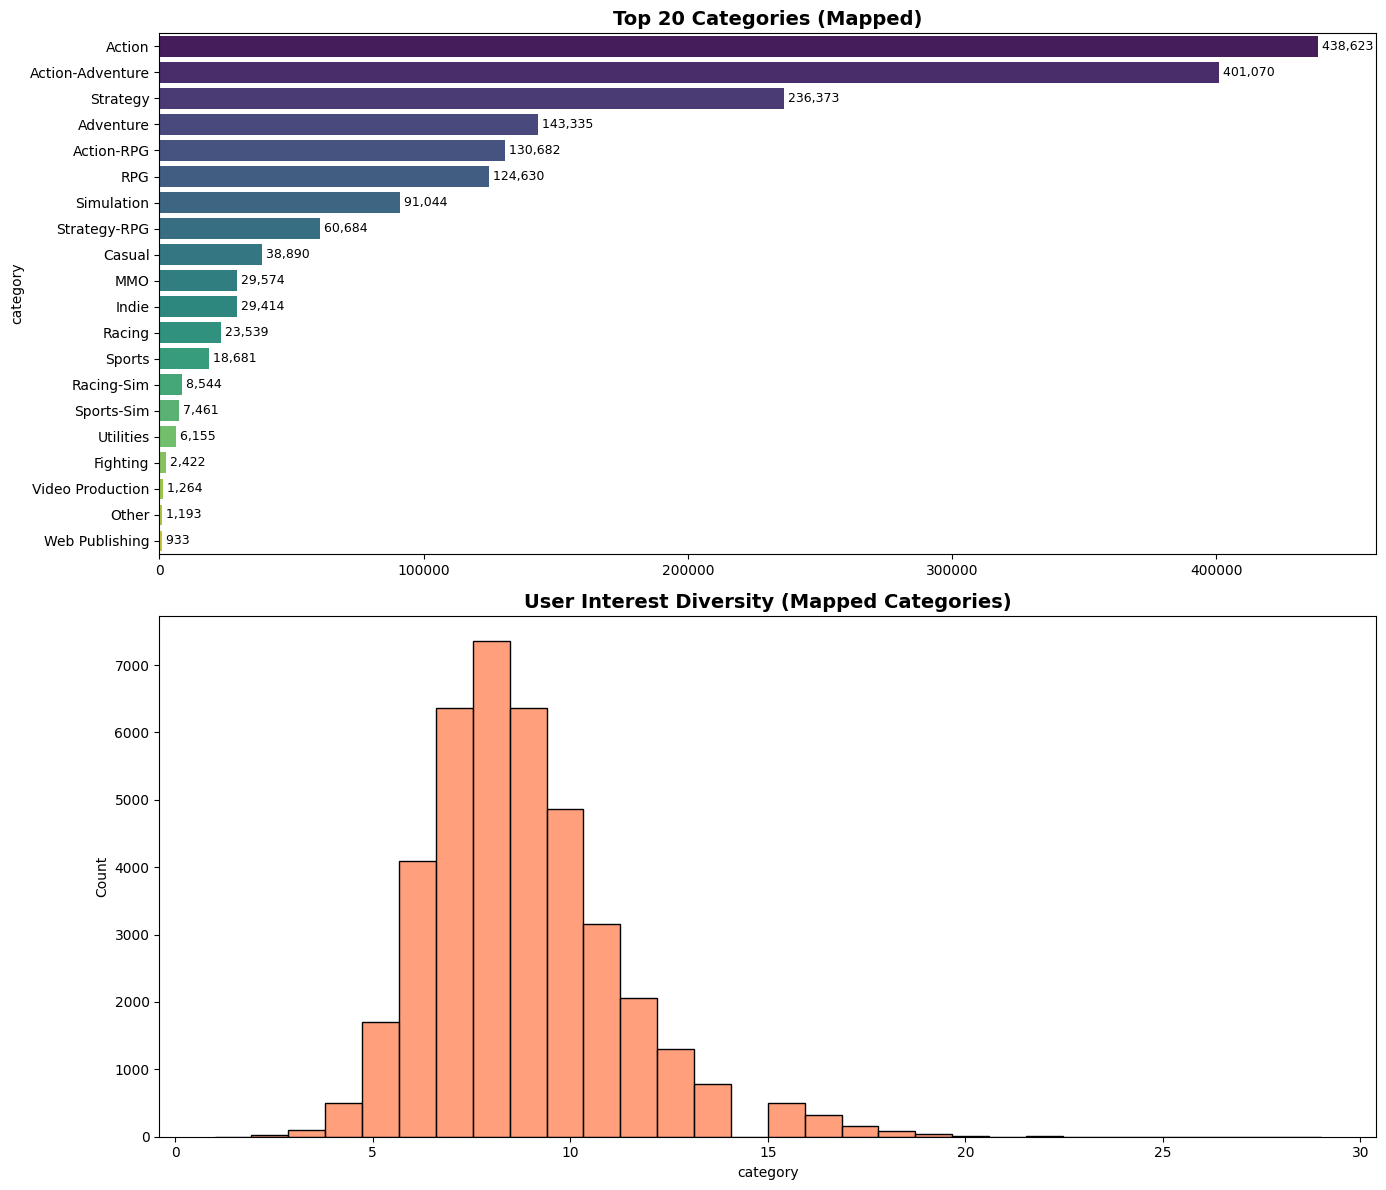

In [ ]:


import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============= Configuration =============
INPUT_FILE = 'steam_sequential_dataset.csv'
OUTPUT_FILE = 'steam_sequential_mapped.csv'
IMAGE_FILE = 'category_distribution_analysis.png'

# ============= Category Mapping Function =============
def map_category(category_combination):

    if pd.isna(category_combination) or category_combination == "Unknown":
        return "Other"
    
    cat_lower = str(category_combination).lower()
    
    combo_categories = {
        ('action', 'adventure'): 'Action-Adventure',
        ('action', 'rpg'): 'Action-RPG',
        ('strategy', 'rpg'): 'Strategy-RPG',
        ('racing', 'simulation'): 'Racing-Sim',
        ('sports', 'simulation'): 'Sports-Sim',
        ('tower defense', 'strategy'): 'Tower Defense',
        ('visual novel', 'rpg'): 'Visual Novel',
    }
    
    for combo_keys, combo_name in combo_categories.items():
        if all(key in cat_lower for key in combo_keys):
            return combo_name

    primary_categories = {
        'utilities': 'Utilities',
        'animation & modeling': 'Animation & Modeling',
        'design & illustration': 'Design & Illustration',
        'video production': 'Video Production',
        'audio production': 'Audio Production',
        'software training': 'Software Training',
        'web publishing': 'Web Publishing',
        'education': 'Education',
        'game development': 'Game Development',
        'photo editing': 'Photo Editing',

        'racing': 'Racing',
        'sports': 'Sports',
        'flight': 'Simulation',
        'puzzle': 'Puzzle',
        'music': 'Music',
        'fighting': 'Fighting',
        'horror': 'Horror',
        'rts': 'RTS',
        'moba': 'MOBA',
        'tower defense': 'Tower Defense',
        'card game': 'Card Game',
        'visual novel': 'Visual Novel',
        
        'strategy': 'Strategy',
        'rpg': 'RPG',
        'simulation': 'Simulation',
        'tactical': 'Strategy',

        'shooter': 'Shooter',
        'fps': 'Shooter',
        'platformer': 'Platformer',
        'rogue': 'Roguelike',
        'metroidvania': 'Action-Adventure',
        'hack and slash': 'Action',
        'massively multiplayer': 'MMO',
        
        'action': 'Action',
        'adventure': 'Adventure',
        'casual': 'Casual',
        'arcade': 'Arcade',

        'anime': 'Anime',
        'movie': 'Movie',
        'episodic': 'Episodic',
        'indie': 'Indie',
    }
    
    for key, main_cat in primary_categories.items():
        if key in cat_lower:
            return main_cat
    

    parts = str(category_combination).split('|')
    if parts and parts[0].strip():
        fallback = parts[0].strip()
        if fallback in ['Early Access', 'Free to Play']:
            return 'Other'
        return fallback
    
    return 'Other'

# ============= Main Processing =============

def run_mapping_pipeline():
    print("=" * 60)
    print("STEAM CATEGORY MAPPING (Overwrite Mode)")
    print("=" * 60)

    print(f"\n[1/4] Loading {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE)
        print(f"   Dataset loaded: {len(df):,} records")

        if 'hours' in df.columns:
            print(f"   [CHECK] 'hours' column exists. (Mean: {df['hours'].mean():.2f})")
    except FileNotFoundError:
        print(f"Error: no {INPUT_FILE}")
        return

    if not df.empty:
        print("\n[2/4] Mapping categories and overwriting 'category' column...")
        
        raw_unique = df['category'].nunique()
        

        df['category'] = df['category'].apply(map_category)
        
        mapped_unique = df['category'].nunique()
        print(f"   Mapping complete: Reduced {raw_unique} complex types to {mapped_unique} primary types.")

        print(f"\n[3/4] Saving to {OUTPUT_FILE}...")
        
        df.to_csv(OUTPUT_FILE, index=False)
        print(f"   Saved successfully! Path: {os.path.abspath(OUTPUT_FILE)}")
        print(f"   Final Columns: {list(df.columns)}")

        # ============= Visualization =============
        print("\n[4/4] Generating Visualization...")
        try:
            fig, axes = plt.subplots(2, 1, figsize=(14, 12))

            # Plot 1: Top 20 Categories
            top_categories = df['category'].value_counts().head(20)
            sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0], palette='viridis')
            axes[0].set_title('Top 20 Categories (Mapped)', fontsize=14, fontweight='bold')
            for i, v in enumerate(top_categories.values):
                axes[0].text(v, i, f' {v:,}', va='center', fontsize=9)

            # Plot 2: User Diversity
            user_diversity = df.groupby('user_id')['category'].nunique()
            sns.histplot(user_diversity, bins=30, kde=False, ax=axes[1], color='coral')
            axes[1].set_title('User Interest Diversity (Mapped Categories)', fontsize=14, fontweight='bold')
            
            plt.tight_layout()
            plt.savefig(IMAGE_FILE, dpi=300, bbox_inches='tight')
            print(f"   Plot saved as '{IMAGE_FILE}'")
            plt.show()
            
        except Exception as e:
            print(f"Visualization error: {e}")

if __name__ == "__main__":
    run_mapping_pipeline()